# Taylor Martin's Notebook
# P2: Text Preprocessing

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Taylor Martin](https://github.com/tmartin-m/)
- Repository: [nlp-02-text-preprocessing](https://github.com/tmartin-m/nlp-02-text-processing/)
- Purpose: Demonstrate text pre-processing
- Date: 2026-03

This is a Markdown cell.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

WHY:
- Keeps notebooks readable and reproducible
- Mirrors professional scripts
- Makes requirements clear

This is a Markdown cell.

In [104]:
# Section 1 Python cell.

# Imports at the top of the file
# REQ: External packages must be defined in pyproject.toml
# REQ: External packages must be installed in the environment using `uv sync` command
# REQ: External packages used in this notebook must be imported here

from pathlib import Path
import re

import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


## Section 2. Read the Text Data

This is a Markdown cell.

In [105]:
# Section 2 Python cell

# In notebooks, start with the current working directory
# where the notebook is located.
NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent

DATA_PATH: Path = ROOT_PATH / "data"
NOTEBOOKS_PATH: Path = ROOT_PATH / "notebooks"
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

# Choose a text file to analyze.
# Each line is treated as one text record.
input_path: Path = DATA_PATH / "no_tmartin.txt"

# Read all lines from the file.
text_list: list[str] = input_path.read_text(encoding="utf-8").splitlines()

# Remove blank lines.
text_list = [line.strip() for line in text_list if line.strip()]

print("Data loaded successfully.")
print(f"Loaded {len(text_list):,} text records.")

# Combine all text rows into one large string for simple preprocessing.
raw_text: str = " ".join(text_list)

print(f"Raw text length: {len(raw_text):,} characters")
print("First 500 characters of raw text:")
print(raw_text[:500])

Data loaded successfully.
Loaded 2,613 text records.
Raw text length: 128,274 characters
First 500 characters of raw text:
THE ART OF SAYING NO HOW TO STAND YOUR GROUND, RECLAIM YOUR TIME AND ENERGY, AND REFUSE TO BE TAKEN FOR GRANTED (WITHOUT FEELING GUILTY!) DAMON ZAHARIADES In the following pages, I’m going to teach you how to say no with conﬁdence and without guilt. Along the way, you’ll develop the assertiveness you need to turn down requests if they fail to align with your goals, needs, and convictions. NOTABLE QUOTABLES ABOUT SAYING NO If you don't prioritize your life, someone else will.- Greg McKeown A 'no'


## Section 3. Inspect the Raw Text

This is a Markdown cell.

In [106]:
# Section 3 Python cell

# Review the text records before preprocessing.
# This helps confirm the data loaded correctly and gives a
# sense of the structure of the text.

print("First 5 text records:")
for line in text_list[:5]:
    print("-", line)

print(f"\nLoaded {len(text_list):,} text records.")
print(f"Raw text length: {len(raw_text):,} characters")

print("\nFirst 500 characters of combined text:")
print(raw_text[:500])

First 5 text records:
- THE ART OF SAYING NO
- HOW TO STAND YOUR GROUND, RECLAIM YOUR TIME AND ENERGY, AND REFUSE TO BE TAKEN FOR GRANTED (WITHOUT FEELING GUILTY!)
- DAMON ZAHARIADES
- In the following pages, I’m going to teach you how to say no with conﬁdence and
- without guilt. Along the way, you’ll develop the assertiveness you need to turn down

Loaded 2,613 text records.
Raw text length: 128,274 characters

First 500 characters of combined text:
THE ART OF SAYING NO HOW TO STAND YOUR GROUND, RECLAIM YOUR TIME AND ENERGY, AND REFUSE TO BE TAKEN FOR GRANTED (WITHOUT FEELING GUILTY!) DAMON ZAHARIADES In the following pages, I’m going to teach you how to say no with conﬁdence and without guilt. Along the way, you’ll develop the assertiveness you need to turn down requests if they fail to align with your goals, needs, and convictions. NOTABLE QUOTABLES ABOUT SAYING NO If you don't prioritize your life, someone else will.- Greg McKeown A 'no'


## Section 4. Tokenize the Raw Text

This is a Markdown cell.

In [107]:
# Section 4 Python cell

# Split the raw text into rough word-like pieces using whitespace.
raw_tokens: list[str] = raw_text.split()
count_of_raw_tokens: int = len(raw_tokens)

print("First 20 raw tokens:")
print(raw_tokens[:20])
print(f"Total raw tokens: {count_of_raw_tokens:,}")

First 20 raw tokens:
['THE', 'ART', 'OF', 'SAYING', 'NO', 'HOW', 'TO', 'STAND', 'YOUR', 'GROUND,', 'RECLAIM', 'YOUR', 'TIME', 'AND', 'ENERGY,', 'AND', 'REFUSE', 'TO', 'BE', 'TAKEN']
Total raw tokens: 22,213


## Section 5. Normalize the Text

This is a Markdown cell.

In [108]:
# Section 5 Python cell

# Convert all text to lowercase so words like "Data" and "data"
# are treated as the same token.
lower_text: str = raw_text.lower()

print("First 500 characters of lowercase text:")
print(lower_text[:500])

First 500 characters of lowercase text:
the art of saying no how to stand your ground, reclaim your time and energy, and refuse to be taken for granted (without feeling guilty!) damon zahariades in the following pages, i’m going to teach you how to say no with conﬁdence and without guilt. along the way, you’ll develop the assertiveness you need to turn down requests if they fail to align with your goals, needs, and convictions. notable quotables about saying no if you don't prioritize your life, someone else will.- greg mckeown a 'no'


## Section 6. Remove Punctuation and Tokenize Again


This is a Markdown cell.

In [109]:
# Section 6 Python cell

# Replace any character that is not a letter, number, or whitespace
# with a space. This removes punctuation and many special characters.
no_punct_text: str = re.sub(r"[^a-z0-9\s]", " ", lower_text)

# Tokenize again after punctuation removal.
tokens_no_punct: list[str] = no_punct_text.split()
count_of_tokens_no_punct: int = len(tokens_no_punct)

print("First 20 tokens after lowercasing and punctuation removal:")
print(tokens_no_punct[:20])
print(f"Total tokens after punctuation removal: {count_of_tokens_no_punct:,}")

First 20 tokens after lowercasing and punctuation removal:
['the', 'art', 'of', 'saying', 'no', 'how', 'to', 'stand', 'your', 'ground', 'reclaim', 'your', 'time', 'and', 'energy', 'and', 'refuse', 'to', 'be', 'taken']
Total tokens after punctuation removal: 23,385


## Section 7. Remove Stop Words


This is a Markdown cell.

In [110]:
# Section 7 Python cell

# Stop words are very common words that often add little meaning
# for simple frequency analysis.
STOP_WORDS: set[str] = {
    "a",
    "all",
    "an",
    "and",
    "are",
    "as",
    "at",
    "be",
    "but",
    "by",
    "don",
    "for",
    "from",
    "had",
    "has",
    "have",
    "he",
    "her",
    "him",
    "his",
    "in",
    "is",
    "it",
    "its",
    "ll",
    "me",
    "my",
    "of",
    "on",
    "or",
    "our",
    "re",
    "said",
    "she",
    "so",
    "some",
    "that",
    "the",
    "then",
    "there",
    "they",
    "this",
    "to",
    "was",
    "we",
    "what",
    "when",
    "where",
    "who",
    "were",
    "will",
    "with",
    "you",
    "your",
}

# Keep only tokens that:
# - are longer than 2 characters
# - are not in the stop word list
clean_tokens: list[str] = [
    token for token in tokens_no_punct if len(token) > 1 and token not in STOP_WORDS
]

count_of_clean_tokens: int = len(clean_tokens)

print("First 20 cleaned tokens:")
print(clean_tokens[:20])
print(f"Total cleaned tokens: {count_of_clean_tokens:,}")

First 20 cleaned tokens:
['art', 'saying', 'no', 'how', 'stand', 'ground', 'reclaim', 'time', 'energy', 'refuse', 'taken', 'granted', 'without', 'feeling', 'guilty', 'damon', 'zahariades', 'following', 'pages', 'going']
Total cleaned tokens: 12,915


## Section 8. Build a Before/After Summary Table


This is a Markdown cell.

In [111]:
# Section 8 Python cell

summary_df: pl.DataFrame = pl.DataFrame(
    {
        "stage": [
            "raw tokens",
            "after punctuation removal",
            "after stop word removal",
        ],
        "count": [
            count_of_raw_tokens,
            count_of_tokens_no_punct,
            count_of_clean_tokens,
        ],
    }
)

print("Preprocessing summary:")
print(summary_df)

Preprocessing summary:
shape: (3, 2)
┌───────────────────────────┬───────┐
│ stage                     ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ i64   │
╞═══════════════════════════╪═══════╡
│ raw tokens                ┆ 22213 │
│ after punctuation removal ┆ 23385 │
│ after stop word removal   ┆ 12915 │
└───────────────────────────┴───────┘


## Section 9. Build a Frequency Table with Polars

This is a Markdown cell.

In [112]:
# Section 9 Python cell

# Create a Polars DataFrame with one row per cleaned token.
token_df: pl.DataFrame = pl.DataFrame({"token": clean_tokens})

# Group by token, count occurrences, and sort from most common to least common.
freq_df: pl.DataFrame = token_df.group_by("token").len().sort("len", descending=True)

print("Top 20 most frequent cleaned tokens:")
print(freq_df.head(20))

Top 20 most frequent cleaned tokens:
shape: (20, 2)
┌──────────┬─────┐
│ token    ┆ len │
│ ---      ┆ --- │
│ str      ┆ u64 │
╞══════════╪═════╡
│ no       ┆ 278 │
│ say      ┆ 177 │
│ can      ┆ 160 │
│ help     ┆ 153 │
│ time     ┆ 138 │
│ …        ┆ …   │
│ own      ┆ 68  │
│ requests ┆ 67  │
│ more     ┆ 67  │
│ take     ┆ 66  │
│ not      ┆ 64  │
└──────────┴─────┘


## Section 10. Build a "Most Frequent Cleaned Tokens" Bar Chart


This is a Markdown cell.

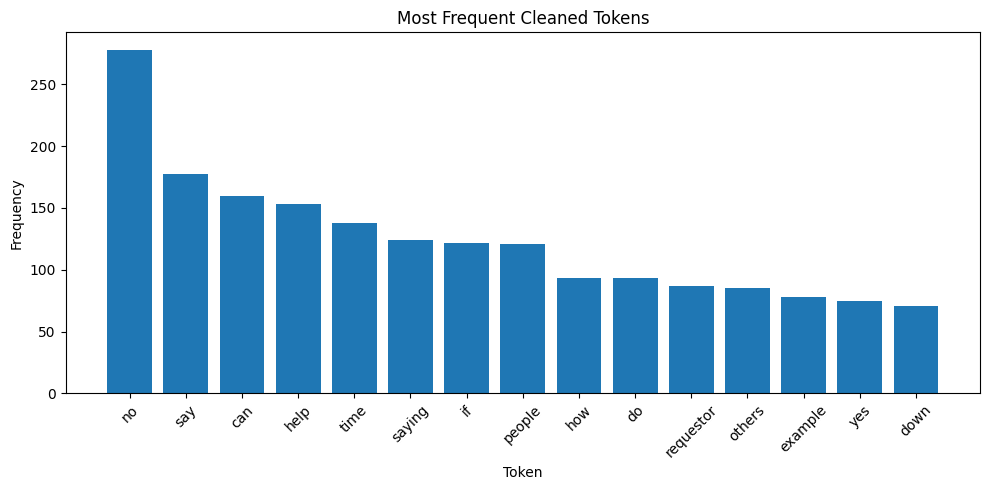

In [113]:
# Section 10 Python cell

top_df: pl.DataFrame = freq_df.head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_df["token"], top_df["len"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=45)

plt.title("Most Frequent Cleaned Tokens")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

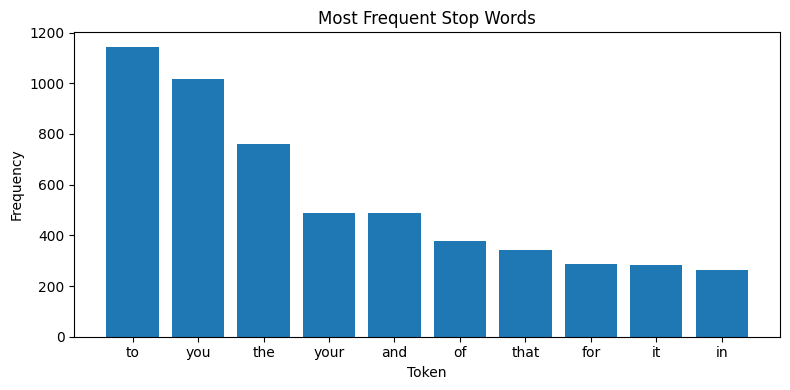

In [114]:
removed_tokens = [t for t in tokens_no_punct if len(t) > 1 and t in STOP_WORDS]

removed_df = (
    pl.DataFrame({"token": removed_tokens})
    .group_by("token")
    .len()
    .sort("len", descending=True)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.bar(removed_df["token"], removed_df["len"])
plt.title("Most Frequent Stop Words")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Section 11. Compare Raw vs Clean Token Counts


This is a Markdown cell.

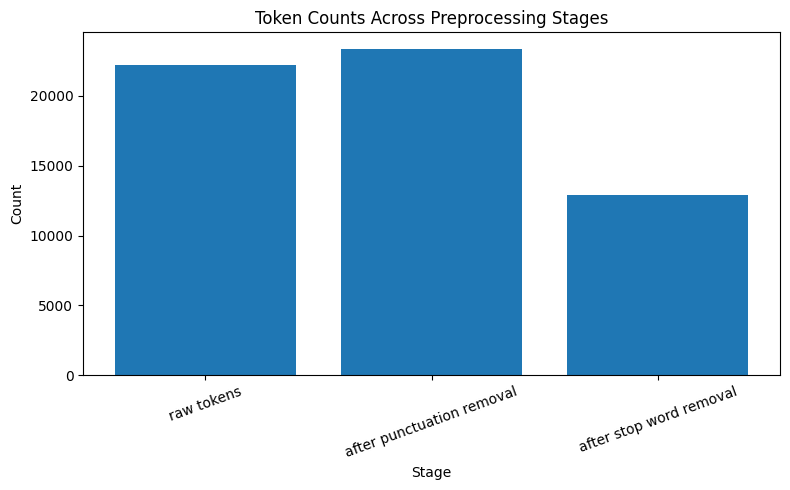

In [115]:
# Section 11 Python cell

plt.figure(figsize=(8, 5))
plt.bar(summary_df["stage"], summary_df["count"])

ax = plt.gca()
ax.tick_params(axis="x", labelrotation=20)

plt.title("Token Counts Across Preprocessing Stages")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Reminder: "Run All" before sending to GitHub

Before saving a notebook (and running git add-commit-push),
**click 'Run All'** to generate all outputs and display them in the notebook. 

After git add-commit-push, **verify your notebook appears** in your GitHub repo. 

This is a Markdown cell.
